In [1]:
import os
os.chdir(os.path.abspath("../../"))

In [2]:
import os
import pandas as pd 

target_dir = r'data' 
if os.path.exists(target_dir): 
    print("Folder found! Files inside:") 
    print(os.listdir(target_dir)) 
else: 
    print("Folder NOT found. Check the path again.")


file_path = r'data/apartments_for_rent_classified_10K.csv'
try:
    df_apartments = pd.read_csv(file_path, sep=';', encoding='ISO-8859-1')
    print("File loaded successfully. Here's a preview:")
    print(f"Data size：{df_apartments.shape[0]} row, {df_apartments.shape[1]} column")
    display(df_apartments.head(1))
except Exception as e:
    print(f"Error loading file: {e}")

df = df_apartments

Folder found! Files inside:
['apartments_for_rent_classified_100K.csv', 'apartments_for_rent_classified_10K.csv', 'processed']
File loaded successfully. Here's a preview:
Data size：10000 row, 22 column


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415


In [2]:
df["price_type"].value_counts(dropna=False).head(30)

price_type
Monthly           9998
Weekly               1
Monthly|Weekly       1
Name: count, dtype: int64

In [3]:
df["price_type_std"] = df["price_type"].str.lower().str.strip()

df["price_monthly"] = df["price"]

In [4]:
# 处理 weekly
weekly_mask = df["price_type_std"].str.contains("week", na=False)
df.loc[weekly_mask, "price_monthly"] = df.loc[weekly_mask, "price"] * 52/12

C:\Users\School_work\AppData\Local\Temp\ipykernel_37100\1654105626.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[6760.         1191.66666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[weekly_mask, "price_monthly"] = df.loc[weekly_mask, "price"] * 52/12


In [5]:
df.loc[df["price_type_std"] == "monthly|weekly", "price_monthly"] = df["price"]

In [6]:
[c for c in df.columns if "time" in c.lower() or "date" in c.lower()]

['time']

In [7]:
df["datetime"] = pd.to_datetime(df["time"], unit="s", errors="coerce")

In [8]:
df["datetime"].isna().sum()

0

In [9]:
df['time'].head(2)

0    1577359415
1    1577017063
Name: time, dtype: int64

In [10]:
import pandas as pd
import numpy as np
import re

# ==========================================
# 0) Load and preserve original dataset
# ==========================================
# Keep a deep copy of the original dataset for safety
df_raw = df.copy(deep=True)

print("Original shape:", df.shape)


# ==========================================
# 1) Drop unnecessary columns
# ==========================================
# Remove redundant or non-analytical fields
drop_cols = ["price_display", "address"]
to_drop = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=to_drop)

print("Dropped columns:", to_drop)
print("Shape after drop:", df.shape)


# ==========================================
# 2) Convert time variable into readable datetime
# ==========================================
# Identify possible time-related column names
time_candidates = ["time", "timestamp", "created", "created_time", "date", "datetime"]
time_col = next((c for c in time_candidates if c in df.columns), None)

if time_col is None:
    print("Warning: No time column found.")
else:
    s = df[time_col]

    # If numeric, assume Unix timestamp (seconds or milliseconds)
    if pd.api.types.is_numeric_dtype(s):
        median_val = np.nanmedian(s.values)
        unit = "ms" if median_val > 1e11 else "s"
        df["datetime"] = pd.to_datetime(s, unit=unit, errors="coerce")
    else:
        # Otherwise attempt direct parsing
        df["datetime"] = pd.to_datetime(s, errors="coerce")

    print(f"Time column used: {time_col}")
    print("Non-null datetime entries:", int(df["datetime"].notna().sum()))


# ==========================================
# 3) Standardize price_type and convert all prices to monthly
# ==========================================
price_col = "price" if "price" in df.columns else None
ptype_col = "price_type" if "price_type" in df.columns else None

if price_col is None:
    print("Warning: No price column found.")
else:
    # Convert price to numeric
    df["price_num"] = pd.to_numeric(df[price_col], errors="coerce")

    if ptype_col is None:
        # If no price_type column exists, assume monthly pricing
        df["price_type_std"] = "monthly"
        df["price_monthly"] = df["price_num"]
        print("Warning: No price_type column found. Assuming monthly prices.")
    else:
        # Normalize price_type text
        p = (
            df[ptype_col]
            .fillna("")
            .astype(str)
            .str.lower()
            .str.strip()
        )

        def normalize_price_type(x: str) -> str:
            if "month" in x: return "monthly"
            if "week" in x:  return "weekly"
            if "day" in x:   return "daily"
            if "year" in x or "ann" in x: return "yearly"
            return "unknown"

        df["price_type_std"] = p.apply(normalize_price_type)

        # Convert all price units into monthly equivalent
        conversion_factor = {
            "monthly": 1.0,
            "weekly": 52/12,
            "daily": 365/12,
            "yearly": 1/12
        }

        df["price_monthly"] = df.apply(
            lambda r: r["price_num"] * conversion_factor.get(r["price_type_std"], np.nan),
            axis=1
        )

        print("Price type distribution:")
        print(df["price_type_std"].value_counts(dropna=False))


# ==========================================
# 4) Handle obvious invalid values
# ==========================================
# Replace square_feet == 0 with NaN (clearly invalid)
sq_col = "square_feet" if "square_feet" in df.columns else None

if sq_col is None:
    print("Warning: No square_feet column found.")
else:
    df[sq_col] = pd.to_numeric(df[sq_col], errors="coerce")
    zero_count = (df[sq_col] == 0).sum()
    df.loc[df[sq_col] == 0, sq_col] = np.nan
    print(f"square_feet == 0 replaced with NaN: {int(zero_count)}")


# ==========================================
# 5) Standardize text fields (amenities / body)
# ==========================================
def clean_text_series(s: pd.Series) -> pd.Series:
    """
    Standardize textual content by:
    - Replacing missing values with empty string
    - Converting to string
    - Removing extra whitespace
    - Trimming leading/trailing spaces
    """
    return (
        s.fillna("")
         .astype(str)
         .str.replace(r"\s+", " ", regex=True)
         .str.strip()
    )

if "amenities" in df.columns:
    df["amenities_clean"] = clean_text_series(df["amenities"]).str.lower()
    df["amenities_clean"] = df["amenities_clean"].str.replace(r"[;/|]+", ",", regex=True)

if "body" in df.columns:
    df["body_clean"] = clean_text_series(df["body"]).str.lower()

print("Clean text columns created.")


# ==========================================
# 6) Generate cleaning summary report
# ==========================================
summary = {}

if "price_num" in df.columns:
    summary["price_num_missing"] = int(df["price_num"].isna().sum())

if "price_monthly" in df.columns:
    summary["price_monthly_missing"] = int(df["price_monthly"].isna().sum())

if sq_col:
    summary["square_feet_missing"] = int(df[sq_col].isna().sum())

if "datetime" in df.columns:
    summary["datetime_missing"] = int(df["datetime"].isna().sum())
    summary["datetime_min"] = str(df["datetime"].min())
    summary["datetime_max"] = str(df["datetime"].max())

print("\n===== Cleaning Summary =====")
for k, v in summary.items():
    print(f"{k}: {v}")

display(df.head(2))

Original shape: (10000, 25)
Dropped columns: ['price_display', 'address']
Shape after drop: (10000, 23)
Time column used: time
Non-null datetime entries: 10000
Price type distribution:
price_type_std
monthly    9999
weekly        1
Name: count, dtype: int64
square_feet == 0 replaced with NaN: 0
Clean text columns created.

===== Cleaning Summary =====
price_num_missing: 0
price_monthly_missing: 0
square_feet_missing: 0
datetime_missing: 0
datetime_min: 2019-09-17 18:12:56
datetime_max: 2019-12-26 12:09:46


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,latitude,longitude,source,time,price_type_std,price_monthly,datetime,price_num,amenities_clean,body_clean
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,38.9057,-76.9861,RentLingo,1577359415,monthly,790.0,2019-12-26 11:23:35,790,,"this unit is located at second st ne, uhland t..."
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,37.9680,-87.6621,RentLingo,1577017063,monthly,425.0,2019-12-22 12:17:43,425,,"this unit is located at 814 schutte road, evan..."


In [11]:
df["has_photo"].value_counts()

has_photo
Thumbnail    8907
Yes           909
No            184
Name: count, dtype: int64

Data shape: (10000, 22)
Valid rows after cleaning: 10000


C:\Users\School_work\AppData\Local\Temp\ipykernel_37100\2584801685.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups_full, labels=labels_full)


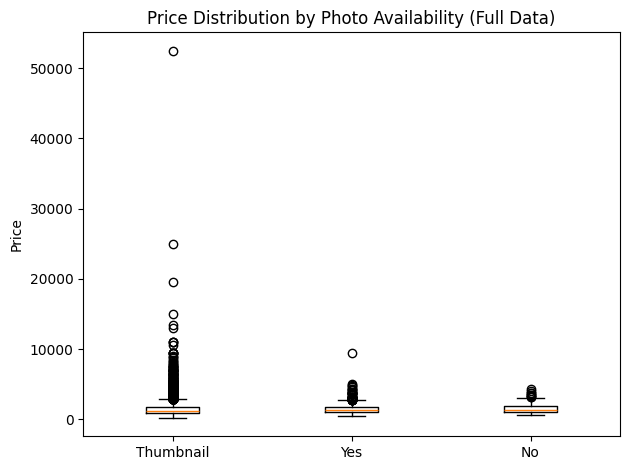

99% threshold: 4995.0
Trimmed sample size: 9906


C:\Users\School_work\AppData\Local\Temp\ipykernel_37100\2584801685.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups_trim, labels=labels_trim)


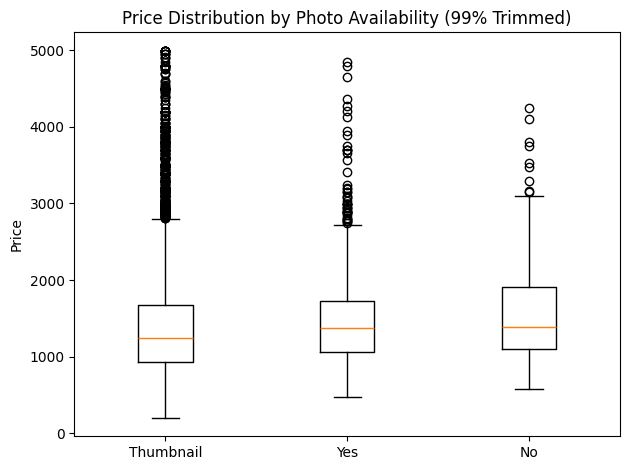


===== Group Statistics (99% trimmed) =====

Group: Thumbnail
Count: 8815
Mean: 1417.0
Median: 1250.0
Std: 714.19

Group: Yes
Count: 907
Mean: 1485.78
Median: 1379.0
Std: 627.11

Group: No
Count: 184
Mean: 1586.52
Median: 1382.5
Std: 725.51


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Load dataset
# =========================

file_path = "data/apartments_for_rent_classified_10K.csv"  # 修改为你的路径
df = pd.read_csv(file_path, sep=';', encoding='ISO-8859-1')

print("Data shape:", df.shape)

# =========================
# 2. Basic cleaning
# =========================

# Ensure price is numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Clean photo column
df["has_photo_clean"] = df["has_photo"].astype(str).str.strip()

# Drop missing price
df_plot = df.dropna(subset=["price", "has_photo_clean"])

print("Valid rows after cleaning:", len(df_plot))

# =========================
# 3. FULL DATA BOXPLOT
# =========================

groups_full = []
labels_full = []

for val in df_plot["has_photo_clean"].unique():
    groups_full.append(df_plot[df_plot["has_photo_clean"] == val]["price"])
    labels_full.append(val)

plt.figure()
plt.boxplot(groups_full, labels=labels_full)
plt.title("Price Distribution by Photo Availability (Full Data)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# =========================
# 4. 99% TRIMMED BOXPLOT
# =========================

price_99 = df_plot["price"].quantile(0.99)
df_trim = df_plot[df_plot["price"] <= price_99]

print("99% threshold:", round(price_99, 2))
print("Trimmed sample size:", len(df_trim))

groups_trim = []
labels_trim = []

for val in df_trim["has_photo_clean"].unique():
    groups_trim.append(df_trim[df_trim["has_photo_clean"] == val]["price"])
    labels_trim.append(val)

plt.figure()
plt.boxplot(groups_trim, labels=labels_trim)
plt.title("Price Distribution by Photo Availability (99% Trimmed)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# =========================
# 5. Print summary statistics
# =========================

print("\n===== Group Statistics (99% trimmed) =====")

for val in df_trim["has_photo_clean"].unique():
    group = df_trim[df_trim["has_photo_clean"] == val]["price"]
    print(f"\nGroup: {val}")
    print("Count:", len(group))
    print("Mean:", round(group.mean(), 2))
    print("Median:", round(group.median(), 2))
    print("Std:", round(group.std(), 2))

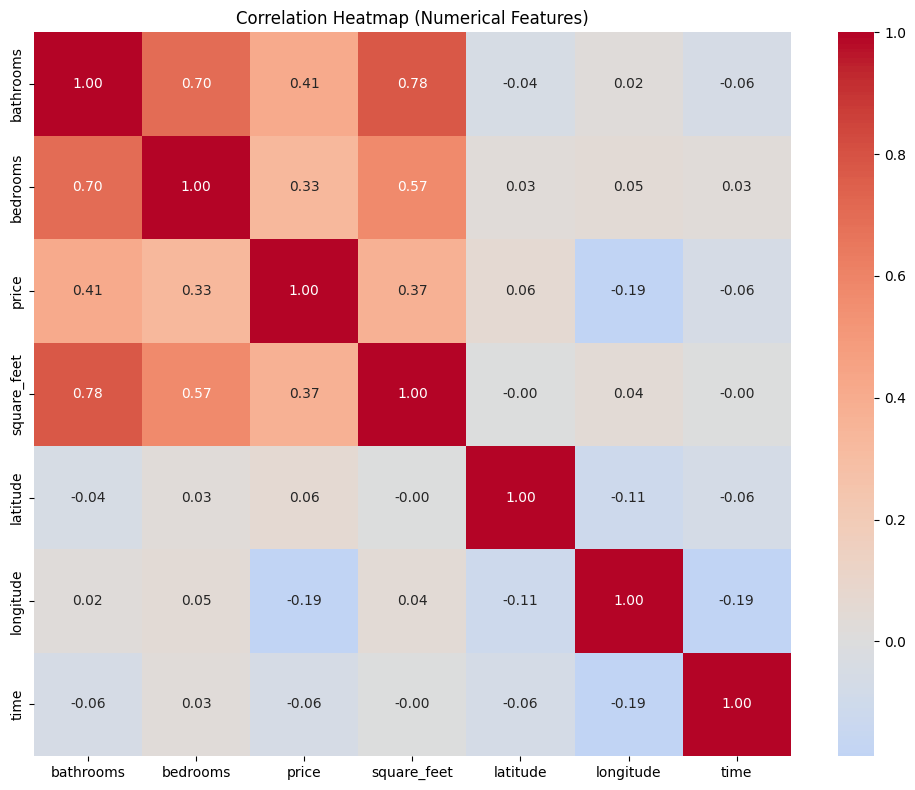

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: select numeric columns
numeric_df = df.select_dtypes(include=["int64", "float64"]).copy()

# Step 2: drop ID-like columns if exist
drop_cols = ["id", "listing_id"]
numeric_df = numeric_df.drop(columns=[col for col in drop_cols if col in numeric_df.columns])

# Step 3: optional trim extreme outliers for clarity
price_99 = numeric_df["price"].quantile(0.99)
numeric_df = numeric_df[numeric_df["price"] <= price_99]

# Step 4: compute correlation
corr = numeric_df.corr()

# Step 5: plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

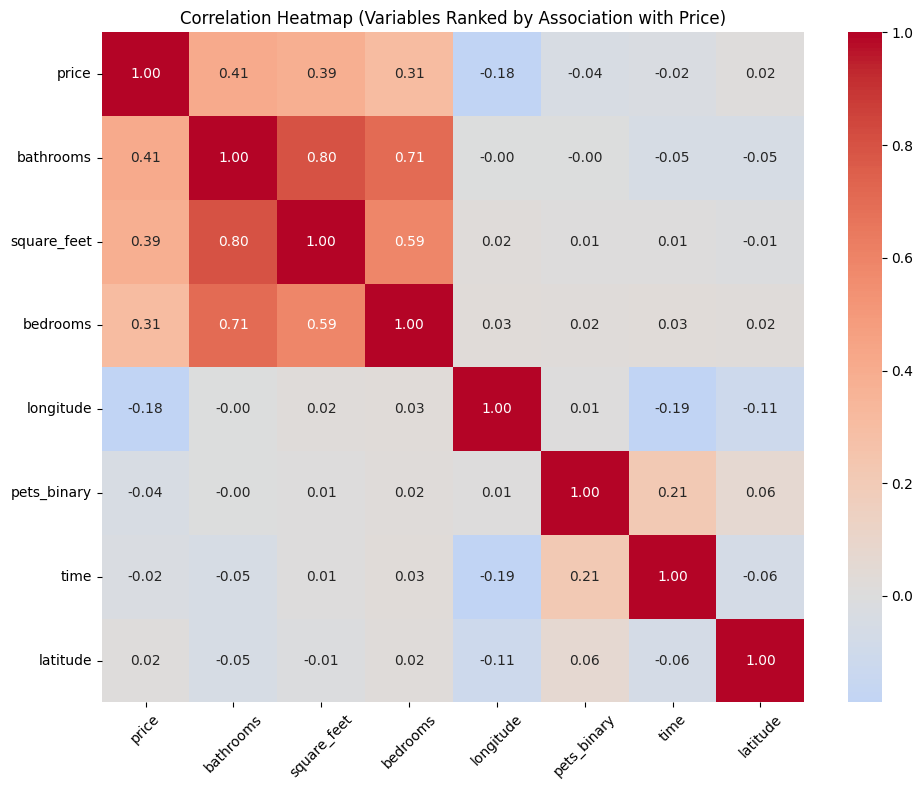

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 选数值列
numeric_df = df_corr_encoded.select_dtypes(include=["number"]).copy()

# 删除无意义列
numeric_df = numeric_df.drop(columns=["id"], errors="ignore")

# 计算相关矩阵
corr_matrix = numeric_df.corr()

# 只看与 price 相关性最大的前 20 个
top_features = (
    corr_matrix["price"]
    .abs()
    .sort_values(ascending=False)
    .index[:10]
)

corr_subset = numeric_df[top_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Variables Ranked by Association with Price)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
print(df_corr.select_dtypes(include=["number"]).columns)

Index(['id', 'bathrooms', 'bedrooms', 'price', 'square_feet', 'latitude',
       'longitude', 'time', 'pets_binary'],
      dtype='object')


In [11]:
# 选择主要 amenity
important_amenities = [
    "Parking",
    "Pool",
    "Gym",
    "Elevator",
    "Washer Dryer"
]

for amenity in important_amenities:
    df[f"amenity_{amenity.lower().replace(' ', '_')}"] = (
        df["amenities"]
        .fillna("")
        .str.contains(amenity, case=False)
        .astype(int)
    )

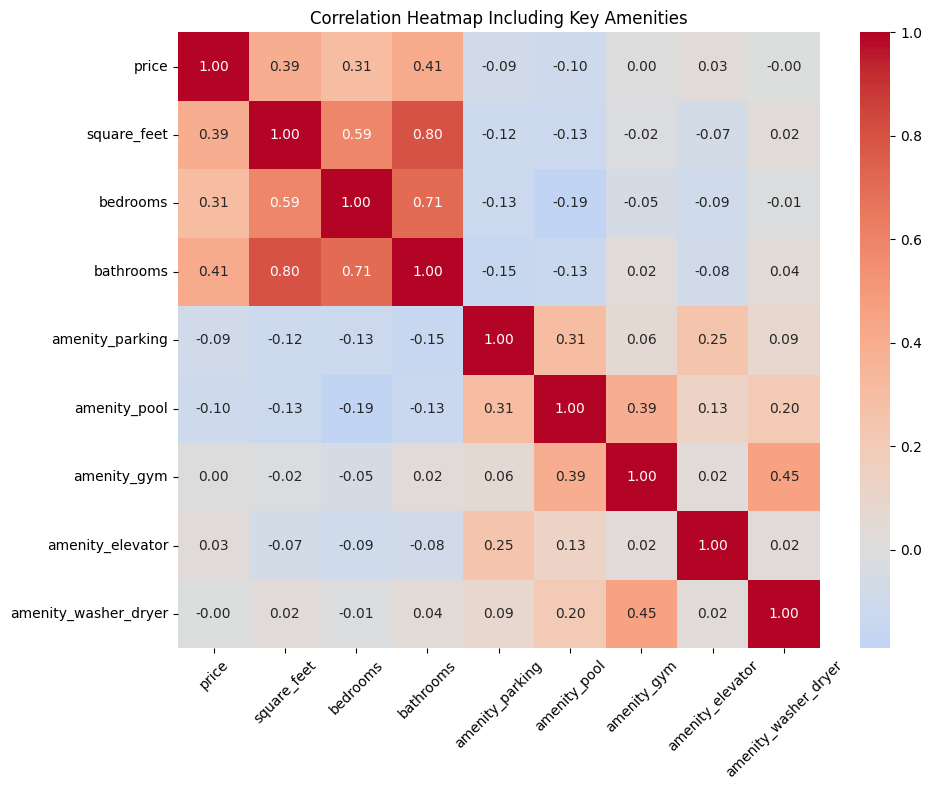

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_for_corr = [
    "price",
    "square_feet",
    "bedrooms",
    "bathrooms",
    "amenity_parking",
    "amenity_pool",
    "amenity_gym",
    "amenity_elevator",
    "amenity_washer_dryer"
]

numeric_df = df[cols_for_corr].copy()

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap Including Key Amenities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()